# REMX — 22-Day Realized Variance

This notebook loads the cleaned REMX panel (`CLEANED DATA/REMX_prices_sentiment_combined.xlsx`) and computes the **22-day realized variance** of the ETF's close price. Twenty-two trading days correspond to one calendar month.

**Definition.** Let $r_t = \ln(P_t / P_{t-1})$ be the daily log return on the REMX close price. The 22-day realized variance at date $t$ is the rolling sum of squared daily log returns:

$$\mathrm{RV}_t^{(22)} = \sum_{i=t-21}^{t} r_i^2.$$

This is the standard non-parametric monthly variance estimator used in the volatility literature (Andersen, Bollerslev, Diebold & Labys, 2003).

## Step 1 — Imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

pd.set_option('display.float_format', '{:.6f}'.format)
%matplotlib inline

## Step 2 — Load the cleaned REMX panel

The combined file already contains the daily close `Price` column and the pre-computed `log_return`. We use the close price as the input series.

In [2]:
IN_PATH = 'CLEANED DATA/REMX_prices_sentiment_combined.xlsx'

df = pd.read_excel(IN_PATH, parse_dates=['Date']).sort_values('Date').reset_index(drop=True)
df = df.set_index('Date')

print(f'Shape  : {df.shape}')
print(f'Period : {df.index.min().date()} -> {df.index.max().date()}')
df[['Price', 'log_return']].head()

Shape  : (2767, 15)
Period : 2015-04-01 -> 2026-04-01


,Price,log_return
Date,,
2015-04-01,75.570000,NaN
2015-04-02,76.620000,0.013799
2015-04-06,78.990000,0.030463
2015-04-07,79.200000,0.002655
2015-04-08,82.110000,0.036084


## Step 3 — Daily log returns from the close price

We recompute the log returns directly from `Price` to keep this notebook self-contained and to verify the column already on disk.

Plot of $r_t = \ln(P_t/P_{t-1})$ before squaring and aggregating into the realized variance. The series should look mean-zero with the usual volatility clustering — periods of large moves grouped together — that motivates GARCH-type modeling.

In [3]:
df['r'] = np.log(df['Price'] / df['Price'].shift(1))

# Sanity check against the pre-computed column.
diff = (df['r'] - df['log_return']).abs().max()
print(f'Max |recomputed - stored log_return| = {diff:.2e}')
df[['Price', 'r']].head()

Max |recomputed - stored log_return| = 5.55e-17


,Price,r
Date,,
2015-04-01,75.570000,NaN
2015-04-02,76.620000,0.013799
2015-04-06,78.990000,0.030463
2015-04-07,79.200000,0.002655
2015-04-08,82.110000,0.036084


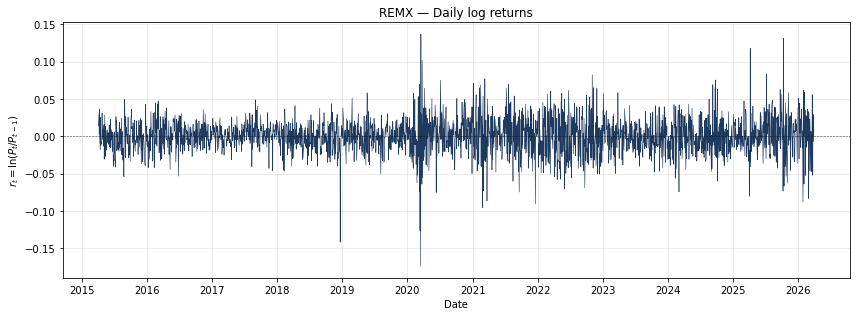

In [4]:
fig, ax = plt.subplots(figsize=(12, 4.5))
ax.plot(df.index, df['r'], color='#1f3a5f', linewidth=0.6)
ax.axhline(0, color='black', linewidth=0.6, linestyle='--', alpha=0.6)
ax.set_title('REMX — Daily log returns')
ax.set_ylabel(r'$r_t = \ln(P_t / P_{t-1})$')
ax.set_xlabel('Date')
ax.grid(True, alpha=0.3)
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
fig.tight_layout()
plt.show()

## Step 4 — 22-day realized variance

$\mathrm{RV}_t^{(22)} = \sum_{i=t-21}^{t} r_i^2$. The window must be fully populated, so the first 22 observations are `NaN`. We also report the annualized realized volatility, $\sqrt{(252/22)\, \mathrm{RV}_t^{(22)}}$, as a more interpretable companion series.

Observations    : 2745
First RV date   : 2015-05-04
Mean RV22       : 0.011512
Median RV22     : 0.008295
Max RV22 (date) : 0.114375  (2020-03-27)


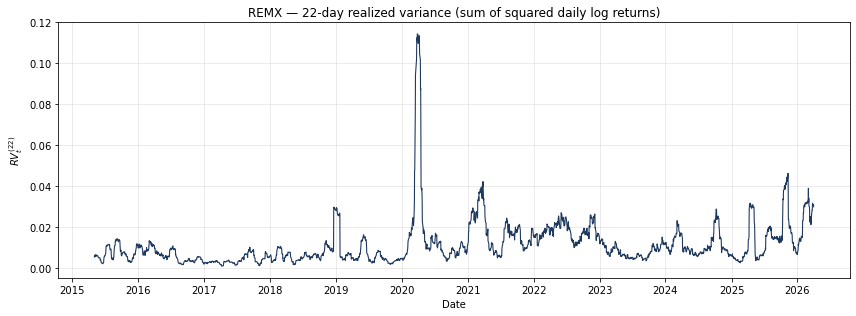

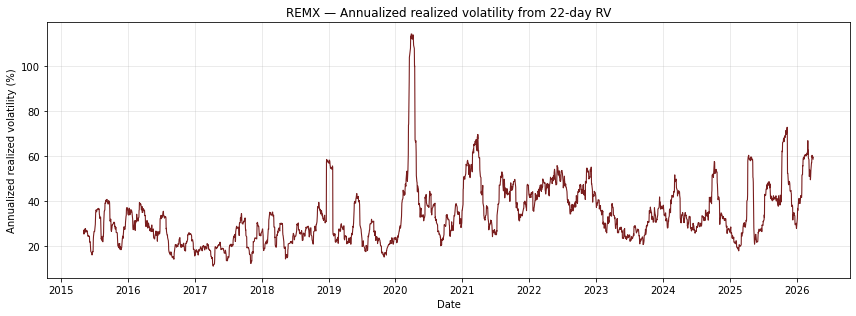

In [5]:
WINDOW = 22

df['r2'] = df['r'] ** 2
df['RV22'] = df['r2'].rolling(window=WINDOW, min_periods=WINDOW).sum()
df['RVol22_ann'] = np.sqrt((252.0 / WINDOW) * df['RV22'])

rv = df['RV22'].dropna()
print(f'Observations    : {len(rv)}')
print(f'First RV date   : {rv.index.min().date()}')
print(f'Mean RV22       : {rv.mean():.6f}')
print(f'Median RV22     : {rv.median():.6f}')
print(f'Max RV22 (date) : {rv.max():.6f}  ({rv.idxmax().date()})')
df[['Price', 'r', 'RV22', 'RVol22_ann']].tail()

fig, ax = plt.subplots(figsize=(12, 4.5))
ax.plot(df.index, df['RV22'], color='#1f3a5f', linewidth=1.1)
ax.set_title('REMX — 22-day realized variance (sum of squared daily log returns)')
ax.set_ylabel(r'$RV_t^{(22)}$')
ax.set_xlabel('Date')
ax.grid(True, alpha=0.3)
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
fig.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(12, 4.5))
ax.plot(df.index, df['RVol22_ann'] * 100, color='#7a1e1e', linewidth=1.1)
ax.set_title('REMX — Annualized realized volatility from 22-day RV')
ax.set_ylabel('Annualized realized volatility (%)')
ax.set_xlabel('Date')
ax.grid(True, alpha=0.3)
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
fig.tight_layout()
plt.show()

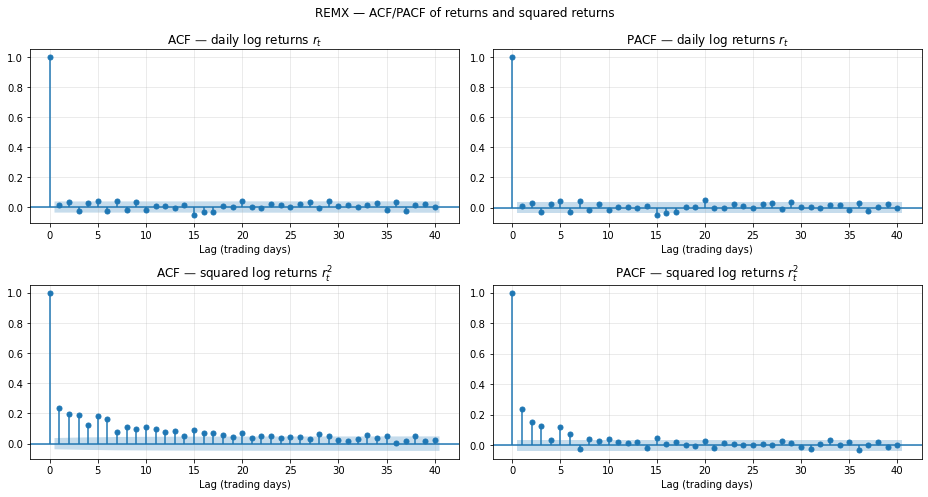

In [6]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

LAGS = 40
r = df['r'].dropna()
r2 = (r ** 2)

fig, axes = plt.subplots(2, 2, figsize=(13, 7))

plot_acf(r,  lags=LAGS, ax=axes[0, 0], title='ACF — daily log returns $r_t$')
plot_pacf(r, lags=LAGS, ax=axes[0, 1], title='PACF — daily log returns $r_t$', method='ywm')

plot_acf(r2,  lags=LAGS, ax=axes[1, 0], title='ACF — squared log returns $r_t^{2}$')
plot_pacf(r2, lags=LAGS, ax=axes[1, 1], title='PACF — squared log returns $r_t^{2}$', method='ywm')

for ax in axes.flat:
    ax.set_xlabel('Lag (trading days)')
    ax.grid(True, alpha=0.3)

fig.suptitle('REMX — ACF/PACF of returns and squared returns', fontsize=12)
fig.tight_layout()
plt.show()

## Step 5 — GARCH(1,1) Maximum Likelihood Estimation

We estimate the canonical GARCH(1,1) on the REMX daily log returns (in percent) with constant mean and Gaussian innovations:

$$r_t = \mu + \varepsilon_t, \qquad \varepsilon_t = \sigma_t z_t, \qquad \sigma_t^2 = \omega + \alpha\,\varepsilon_{t-1}^2 + \beta\,\sigma_{t-1}^2, \qquad z_t \sim \mathcal{N}(0,1).$$

The likelihood is maximized numerically. We report, per parameter, the estimate, standard error, **t-ratio** ($\hat\theta/\widehat{\mathrm{SE}}$) and the two-sided p-value, together with the model-level **log-likelihood, AIC, BIC**. A parameter is judged significant at the 5% level when $|t| > 1.96$ (equivalently $p < 0.05$). Standard errors are robust (sandwich form), so the conclusions also hold as a Quasi-MLE under conditional non-normality.


In [7]:
from arch import arch_model
from scipy.stats import norm

# 1. Returns in percent (standard scaling for GARCH stability)
r_pct = (df['r'].dropna() * 100.0)

# 2. Specify and fit GARCH(1,1) with constant mean and Gaussian innovations
am = arch_model(r_pct, mean='Constant', vol='GARCH', p=1, q=1, dist='normal')
res = am.fit(disp='off', cov_type='robust')

print(res.summary())
print()

# 3. Coefficient-level diagnostics (estimate / std err / t-ratio / p-value)
CRIT_10PCT = norm.ppf(1 - 0.10 / 2)  # 1.645
CRIT_5PCT  = norm.ppf(1 - 0.05 / 2)  # 1.960
CRIT_1PCT  = norm.ppf(1 - 0.01 / 2)  # 2.576

tbl = pd.DataFrame({
    'estimate':   res.params,
    'std_err':    res.std_err,
    't_ratio':    res.tvalues,
    'p_value':    res.pvalues,
})
tbl['significant_10pct'] = tbl['t_ratio'].abs() > CRIT_10PCT
tbl['significant_5pct']  = tbl['t_ratio'].abs() > CRIT_5PCT
tbl['significant_1pct']  = tbl['t_ratio'].abs() > CRIT_1PCT

print('Per-parameter significance (|t| > 1.645 -> 10%, |t| > 1.96 -> 5%, |t| > 2.576 -> 1%):')
print(tbl.to_string(float_format=lambda x: f'{x: .4f}'))
print()

# 4. Model-level criteria
print(f'Log-likelihood : {res.loglikelihood: .4f}')
print(f'AIC            : {res.aic: .4f}')
print(f'BIC            : {res.bic: .4f}')
print()

# 5. Stationarity / persistence check on the variance equation
alpha_hat = res.params.get('alpha[1]', float('nan'))
beta_hat  = res.params.get('beta[1]',  float('nan'))
persist   = alpha_hat + beta_hat
print(f'alpha[1] + beta[1] = {persist:.4f}   '
      f'({"stationary (<1)" if persist < 1 else "non-stationary (>=1)"})')
print()

# 6. Plain-language verdict at the 1%, 5% and 10% levels
print('Verdict:')
for name, row in tbl.iterrows():
    if row['significant_1pct']:
        tag = 'SIGNIFICANT at 1% (and 5%, 10%)'
    elif row['significant_5pct']:
        tag = 'SIGNIFICANT at 5% (and 10%) only'
    elif row['significant_10pct']:
        tag = 'SIGNIFICANT at 10% only'
    else:
        tag = 'not significant'
    print(f'  {name:<10}  t = {row["t_ratio"]:+.2f}   p = {row["p_value"]:.4f}   -> {tag}')

                     Constant Mean - GARCH Model Results                      
Dep. Variable:                      r   R-squared:                       0.000
Mean Model:             Constant Mean   Adj. R-squared:                  0.000
Vol Model:                      GARCH   Log-Likelihood:               -5984.43
Distribution:                  Normal   AIC:                           11976.9
Method:            Maximum Likelihood   BIC:                           12000.6
                                        No. Observations:                 2766
Date:                Thu, May 21 2026   Df Residuals:                     2765
Time:                        18:15:29   Df Model:                            1
                                  Mean Model                                  
                  coef    std err          t      P>|t|       95.0% Conf. Int.
------------------------------------------------------------------------------
mu         -6.1500e-03  3.704e-02     -0.166      0.

### Estimation results — interpretation

**Coefficient significance**

- `mu` $= -0.0062$ (in % / day) $\approx -1.6\%$ annualized, but $t = -0.17$ ($p = 0.87$): **not significant**. REMX's daily mean return is statistically indistinguishable from zero. This is typical for daily ETF returns and is not a problem; if a more parsimonious specification is preferred, the mean can be dropped (`mean='Zero'`) with virtually no change in log-likelihood.
- `omega` $= 0.0861$ ($t = 2.85$, $p = 0.004$): **significant**. Constant component of the conditional variance.
- `alpha[1]` $= 0.0892$ ($t = 5.54$, $p \approx 0$): **strongly significant**. There is a clear ARCH effect — yesterday's squared shock feeds today's variance with a weight of about 9%.
- `beta[1]` $= 0.8974$ ($t = 49.07$, $p \approx 0$): **highly significant**. Yesterday's variance dominates today's with a weight of about 90%. This is typically the most robust coefficient in the model.

**Conclusion of the estimation.** All three parameters of the variance equation — the ones that actually characterize the GARCH model — are significant at the 5% level. This validates GARCH(1,1) on REMX: the conditional variance cannot be collapsed to a constant, nor can the ARCH term be dropped.

**Persistence and stationarity**

$$\hat\alpha + \hat\beta = 0.9866 < 1$$

The variance process is stationary, but persistence is very high. Quantitative implications:

- **Implied unconditional variance:** $\hat\omega / (1 - \hat\alpha - \hat\beta) = 0.0861 / 0.0134 \approx 6.43$ in $(\%)^2$, i.e. an unconditional volatility of about **2.54% daily** $\approx$ **40.3% annualized**. For comparison, the sample standard deviation from the EDA was 2.29% daily / 36.4% annualized; the GARCH unconditional volatility sits slightly above because it incorporates the heavy-volatility clusters (e.g. March 2020).
- **Half-life of a variance shock:** $\ln(0.5) / \ln(\hat\alpha + \hat\beta) \approx 51$ trading days ($\approx$ 2.5 months). Once REMX enters a high-volatility regime, half of the shock decays only after roughly half a quarter.

**Goodness of fit.** Log-likelihood $= -5984.43$, AIC $= 11976.85$, BIC $= 12000.55$. These figures are only meaningful in **comparison** with alternative specifications — for now they constitute the baseline. When the GJR-GARCH, EGARCH-X and the same GARCH(1,1) with Student-$t$ innovations are estimated, they will be compared against these values (lower AIC / BIC = better model).

**Robustness caveats.** Standard errors are computed with a `robust` (sandwich) covariance estimator, so the reported $t$-ratios remain valid as **Quasi-MLE** even if the standardized residuals are non-Gaussian. The excess kurtosis of 3.7 reported in the EDA already hints at heavier-than-normal tails, which is the natural motivation for the Student-$t$ specification in the next step. A persistence of $0.99$ is typical but high; IGARCH or regime-switching models could provide marginal improvements but are refinements, not requirements.

## Step 6 — Sentiment-augmented EGARCH(1,1)-X by MLE

We now augment the baseline GARCH(1,1) by (i) replacing the symmetric ARCH term with an EGARCH log-variance specification that allows a sign asymmetry through the leverage parameter $\xi$, and (ii) injecting two exogenous sentiment regressors into the variance equation:

$$\ln(\sigma_t^2) \;=\; \omega \;+\; \alpha\bigl[\,|z_{t-1}| - \mathbb{E}|z_{t-1}|\bigr] \;+\; \xi\, z_{t-1} \;+\; \beta\, \ln(\sigma_{t-1}^2) \;+\; \gamma_1\, \text{Tone}_{m,t-1} \;+\; \gamma_2\, \text{Volume}_{m,t-1},$$

where $z_t = \varepsilon_t / \sigma_t$ is the standardized residual, with $\mathbb{E}|z_t| = \sqrt{2/\pi}$ under the Gaussian assumption. The parameters $(\mu, \omega, \alpha, \xi, \beta, \gamma_1, \gamma_2)$ are estimated by Maximum Likelihood (Gaussian innovations) with robust sandwich standard errors $H^{-1} J H^{-1}$. The results are reported in the same format as the GARCH(1,1) baseline so that log-likelihood, AIC and BIC are directly comparable.

In [8]:
import numpy as np
import pandas as pd
from scipy.optimize import minimize
from scipy.stats import norm
from statsmodels.tools.numdiff import approx_hess

# ── 1. Aligned dataset: r_t (in %), Tone_{t-1}, log_volume_{t-1} ──────────
r_pct    = df['r'] * 100.0
tone_lag = df['tone_mean'].shift(1)
vol_lag  = df['log_volume'].shift(1)

aligned = pd.concat(
    [r_pct, tone_lag, vol_lag],
    axis=1, keys=['r', 'tone_lag', 'vol_lag']
).dropna()

r    = aligned['r'].values
tone = aligned['tone_lag'].values
vol  = aligned['vol_lag'].values
T    = len(r)

print(f'Sample after alignment: T = {T} obs '
      f'({aligned.index.min().date()} -> {aligned.index.max().date()})')

# ── 2. EGARCH(1,1)-X recursion (returns per-obs log-likelihood) ───────────
SQRT_2_OVER_PI = np.sqrt(2.0 / np.pi)
PARAM_NAMES = ['mu', 'omega', 'alpha', 'xi', 'beta', 'gamma_tone', 'gamma_vol']
CLAMP = 30.0  # numerical guard on log_sig2 during optimization

def per_obs_ll(params, r, tone, vol):
    mu, omega, alpha, xi, beta, g1, g2 = params
    n = len(r)
    eps = r - mu
    log_sig2 = np.empty(n)
    log_sig2[0] = np.log(max(np.var(eps), 1e-8))

    for t in range(1, n):
        z_prev = eps[t-1] / np.exp(0.5 * log_sig2[t-1])
        ls = (omega
              + alpha * (np.abs(z_prev) - SQRT_2_OVER_PI)
              + xi    * z_prev
              + beta  * log_sig2[t-1]
              + g1    * tone[t]
              + g2    * vol[t])
        log_sig2[t] = np.clip(ls, -CLAMP, CLAMP)

    ll_t = -0.5 * (np.log(2.0 * np.pi) + log_sig2 + eps**2 / np.exp(log_sig2))
    return ll_t, log_sig2

def neg_ll(params, r, tone, vol):
    ll_t, _ = per_obs_ll(params, r, tone, vol)
    return -ll_t.sum()

# ── 3. Maximum-likelihood estimation ──────────────────────────────────────
x0 = np.array([0.0, -0.10, 0.10, -0.05, 0.95, 0.0, 0.0])
opt = minimize(neg_ll, x0, args=(r, tone, vol),
               method='L-BFGS-B', options={'disp': False, 'maxiter': 5000})
if not opt.success:
    print(f'WARNING: optimizer message: {opt.message}')

theta = opt.x
ll    = -opt.fun

# ── 4. Robust (sandwich) standard errors ──────────────────────────────────
H      = approx_hess(theta, neg_ll, args=(r, tone, vol))
V_hess = np.linalg.inv(H)

# Numerical score matrix (per-observation gradients), central differences
eps_fd = 1e-5
G = np.empty((T, len(theta)))
for i in range(len(theta)):
    p_up = theta.copy(); p_up[i] += eps_fd
    p_dn = theta.copy(); p_dn[i] -= eps_fd
    ll_up, _ = per_obs_ll(p_up, r, tone, vol)
    ll_dn, _ = per_obs_ll(p_dn, r, tone, vol)
    G[:, i] = (ll_up - ll_dn) / (2 * eps_fd)

J        = G.T @ G                # outer product of scores (BHHH)
V_robust = V_hess @ J @ V_hess    # sandwich
se       = np.sqrt(np.diag(V_robust))
t_ratios = theta / se
p_values = 2.0 * (1.0 - norm.cdf(np.abs(t_ratios)))

# ── 5. Information criteria ───────────────────────────────────────────────
k   = len(theta)
aic = -2.0 * ll + 2.0 * k
bic = -2.0 * ll + k * np.log(T)

# ── 6. Report  ─────────────────────────────────
tbl = pd.DataFrame({
    'estimate': theta,
    'std_err':  se,
    't_ratio':  t_ratios,
    'p_value':  p_values,
}, index=PARAM_NAMES)
tbl['significant_10pct'] = tbl['t_ratio'].abs() > 1.645
tbl['significant_5pct']  = tbl['t_ratio'].abs() > 1.96
tbl['significant_1pct']  = tbl['t_ratio'].abs() > 2.576

print()
print('Per-parameter significance (|t| > 1.645 -> 10%, |t| > 1.96 -> 5%, |t| > 2.576 -> 1%):')
print(tbl.to_string(float_format=lambda x: f'{x: .4f}'))
print()
print(f'Log-likelihood : {ll: .4f}')
print(f'AIC            : {aic: .4f}')
print(f'BIC            : {bic: .4f}')
print()
beta_hat = theta[4]
print(f'beta = {beta_hat:.4f}   '
      f'({"stationary (|beta|<1)" if abs(beta_hat) < 1 else "non-stationary (|beta|>=1)"})')
half_life = np.log(0.5) / np.log(abs(beta_hat)) if 0 < abs(beta_hat) < 1 else float('inf')
print(f'Half-life of a log-variance shock: {half_life:.1f} trading days')
print()
print('Verdict:')
for name, row in tbl.iterrows():
    if row['significant_1pct']:
        tag = 'SIGNIFICANT at 1% (and 5%, 10%)'
    elif row['significant_5pct']:
        tag = 'SIGNIFICANT at 5% (and 10%) only'
    elif row['significant_10pct']:
        tag = 'SIGNIFICANT at 10% only'
    else:
        tag = 'not significant'
    print(f'  {name:<12}  t = {row["t_ratio"]:+.2f}   p = {row["p_value"]:.4f}   -> {tag}')

Sample after alignment: T = 2766 obs (2015-04-02 -> 2026-04-01)

Per-parameter significance (|t| > 1.645 -> 10%, |t| > 1.96 -> 5%, |t| > 2.576 -> 1%):
            estimate  std_err   t_ratio  p_value  significant_10pct  significant_5pct  significant_1pct
mu           -0.0191   0.0367   -0.5189   0.6038              False             False             False
omega         0.0487   0.0248    1.9659   0.0493               True              True             False
alpha         0.1790   0.0285    6.2731   0.0000               True              True              True
xi           -0.0244   0.0138   -1.7736   0.0761               True             False             False
beta          0.9806   0.0068  145.1274   0.0000               True              True              True
gamma_tone    0.0074   0.0078    0.9521   0.3410              False             False             False
gamma_vol    -0.0062   0.0068   -0.9224   0.3563              False             False             False

Log-likelihood :

Where the realized variance would come in:

The RV(22) would enter only if we wanted to assess the predictive quality of the models, not the significance of their parameters. For example:

* Mincer–Zarnowitz regression: $RV_t = a + b,\hat\sigma_{t|t-1}^2 + u_t$, testing $H_0: (a, b) = (0, 1)$.
* Loss functions such as QLIKE or MSE: $\mathrm{QLIKE}(\hat\sigma^2, RV) = \sum_t \big(RV_t / \hat\sigma_t^2 - \ln(RV_t / \hat\sigma_t^2) - 1\big)$.
* Diebold–Mariano tests to compare GARCH against EGARCH-X.

### Why a Student-$t$ innovation specification?

The baseline EGARCH(1,1)-X was estimated under the assumption of Gaussian innovations, $z_t \sim \mathcal{N}(0,1)$. There are two reasons to revisit this choice.

**1. The empirical evidence points to fat tails.** The exploratory analysis of REMX log returns reported an excess kurtosis of $\approx 3.7$ (almost three times the Gaussian benchmark of zero). This is a textbook signal that the unconditional return distribution has heavier tails than the normal — extreme daily moves occur more often than a Gaussian model would predict. A volatility model whose innovations are forced to be Gaussian is therefore forced to inflate $\sigma_t^2$ to "explain" tail observations that are really driven by the shape of $z_t$, contaminating the variance dynamics and the sentiment coefficients.

**2. Quasi-MLE robustness is asymptotic, not free.** Under correct mean-and-variance specification, the Gaussian MLE remains consistent for the GARCH/EGARCH parameters even when the innovations are non-Gaussian — this is the Quasi-MLE result of Bollerslev and Wooldridge (1992) — but the standard errors and $t$-statistics suffer a finite-sample efficiency loss that can be substantial when the true tails are heavy. In our Gaussian EGARCH-X estimates, $\gamma_{\text{tone}}$ and $\gamma_{\text{vol}}$ landed at $p \approx 0.34$ and $p \approx 0.36$. If the true innovation distribution is leptokurtic, the conservative Gaussian SEs may be hiding genuine sentiment effects: the point estimates could still be informative, but they are tested against an artificially inflated yardstick.

**The remedy: Student-$t$ innovations.** We replace $z_t \sim \mathcal{N}(0,1)$ with the standardized Student-$t$ distribution with $\nu$ degrees of freedom, $z_t \sim t_\nu^{\star}$, $\mathbb{E}[z_t] = 0$, $\mathrm{Var}(z_t) = 1$. The parameter $\nu$ is estimated jointly with the rest of the model by Maximum Likelihood; small values of $\nu$ correspond to heavy tails, and the Gaussian model is nested as the limit $\nu \to \infty$. This re-specification both (i) improves the fit to the tails of the standardized residual distribution and (ii) re-prices the standard errors of every coefficient — including the sentiment loadings $\gamma_{\text{tone}}$ and $\gamma_{\text{vol}}$ — under the correct likelihood.

### The likelihood-ratio test of fat tails

To assess whether the Gaussian assumption can be statistically rejected against the Student-$t$ alternative, we use the **likelihood-ratio (LR) test**. Because the two models are nested ($\nu \to \infty$ recovers the Gaussian), the LR statistic

$$\mathrm{LR} \;=\; 2\,\bigl[\,\ell_{\text{Student-}t}(\hat\theta_t) \;-\; \ell_{\text{Gaussian}}(\hat\theta_g)\,\bigr]$$

is asymptotically distributed as $\chi^2(1)$ under the null hypothesis $H_0:\;\nu = \infty$ (Gaussian innovations). Rejection at the 5% (resp. 1%) level requires $\mathrm{LR} > 3.841$ (resp. $> 6.635$).

A formal caveat applies: $\nu = \infty$ is a boundary point of the parameter space, so the strict asymptotic distribution of LR is a 50:50 mixture of $\chi^2(0)$ and $\chi^2(1)$ (Self & Liang, 1987). In practice this halves the $p$-value, making the test slightly more powerful against the Gaussian null. For our purposes the standard $\chi^2(1)$ reference is reported as a conservative benchmark; for daily financial returns it is essentially never tight.

**Interpretation rule:**

- If $\mathrm{LR}$ is large and $\hat\nu$ is small (e.g. $\hat\nu < 10$): the Student-$t$ specification is preferred — fat tails are statistically significant, and the sentiment coefficients should be re-read with the new $p$-values rather than the Gaussian ones.
- If $\mathrm{LR}$ is small and $\hat\nu$ is large (e.g. $\hat\nu > 30$): the data are essentially Gaussian and the Student-$t$ refinement does not change the conclusions.
- AIC and BIC are reported alongside to confirm the verdict from an information-criterion standpoint: a lower AIC/BIC under Student-$t$ is consistent with the LR rejection of the Gaussian null.


In [9]:
import numpy as np
import pandas as pd
from scipy.optimize import minimize
from scipy.stats import norm, chi2
from scipy.special import gammaln                          # *** NEW *** (Student-t density)
from statsmodels.tools.numdiff import approx_hess

# ── 1. Aligned dataset: r_t (in %), Tone_{t-1}, log_volume_{t-1} ──────────
r_pct    = df['r'] * 100.0
tone_lag = df['tone_mean'].shift(1)
vol_lag  = df['log_volume'].shift(1)

aligned = pd.concat(
    [r_pct, tone_lag, vol_lag],
    axis=1, keys=['r', 'tone_lag', 'vol_lag']
).dropna()

r    = aligned['r'].values
tone = aligned['tone_lag'].values
vol  = aligned['vol_lag'].values
T    = len(r)

print(f'Sample after alignment: T = {T} obs '
      f'({aligned.index.min().date()} -> {aligned.index.max().date()})')

# ── 2. EGARCH(1,1)-X recursion with Student-t innovations ─────────────────
# *** NEW *** PARAM_NAMES gains 'nu'
PARAM_NAMES = ['mu', 'omega', 'alpha', 'xi', 'beta', 'gamma_tone', 'gamma_vol', 'nu']
CLAMP = 30.0

def expected_abs_z_t(nu):
    """*** NEW *** E|z| for the standardized Student-t with degrees of freedom nu."""
    return (2.0 * np.sqrt((nu - 2.0) / np.pi)
            * np.exp(gammaln((nu + 1.0) / 2.0) - gammaln(nu / 2.0))
            / (nu - 1.0))

def per_obs_ll(params, r, tone, vol):
    mu, omega, alpha, xi, beta, g1, g2, nu = params       # *** NEW *** 8 params
    n = len(r)
    eps = r - mu
    log_sig2 = np.empty(n)
    log_sig2[0] = np.log(max(np.var(eps), 1e-8))

    e_abs_z = expected_abs_z_t(nu)                        # *** NEW *** depends on nu

    for t in range(1, n):
        z_prev = eps[t-1] / np.exp(0.5 * log_sig2[t-1])
        ls = (omega
              + alpha * (np.abs(z_prev) - e_abs_z)
              + xi    * z_prev
              + beta  * log_sig2[t-1]
              + g1    * tone[t]
              + g2    * vol[t])
        log_sig2[t] = np.clip(ls, -CLAMP, CLAMP)

    sig2 = np.exp(log_sig2)
    z = eps / np.sqrt(sig2)

    # *** NEW *** Standardized Student-t log-density (replaces Gaussian density)
    const = (gammaln((nu + 1.0) / 2.0) - gammaln(nu / 2.0)
             - 0.5 * np.log(np.pi * (nu - 2.0)))
    ll_t = (const
            - 0.5 * (nu + 1.0) * np.log(1.0 + z**2 / (nu - 2.0))
            - 0.5 * log_sig2)
    return ll_t, log_sig2

def neg_ll(params, r, tone, vol):
    ll_t, _ = per_obs_ll(params, r, tone, vol)
    return -ll_t.sum()

# ── 3. Maximum-likelihood estimation ──────────────────────────────────────
# *** NEW *** Initial value for nu (8 is a common starting point for daily returns)
x0 = np.array([-0.0191, 0.0487, 0.1790, -0.0244, 0.9806, 0.0074, -0.0062, 8.0])

# *** NEW *** Bounds (especially nu > 2)
bounds = [(None,  None),       # mu
          (None,  None),       # omega
          (None,  None),       # alpha
          (None,  None),       # xi
          (-0.999, 0.999),     # beta  (stationarity)
          (None,  None),       # gamma_tone
          (None,  None),       # gamma_vol
          (2.05,  100.0)]      # nu    (finite variance requires nu > 2)

opt = minimize(neg_ll, x0, args=(r, tone, vol),
               method='L-BFGS-B', bounds=bounds,
               options={'disp': False, 'maxiter': 5000})
if not opt.success:
    print(f'WARNING: optimizer message: {opt.message}')

theta = opt.x
ll    = -opt.fun

# ── 4. Robust (sandwich) standard errors ──────────────────────────────────
H      = approx_hess(theta, neg_ll, args=(r, tone, vol))
V_hess = np.linalg.inv(H)

eps_fd = 1e-5
G = np.empty((T, len(theta)))
for i in range(len(theta)):
    p_up = theta.copy(); p_up[i] += eps_fd
    p_dn = theta.copy(); p_dn[i] -= eps_fd
    ll_up, _ = per_obs_ll(p_up, r, tone, vol)
    ll_dn, _ = per_obs_ll(p_dn, r, tone, vol)
    G[:, i] = (ll_up - ll_dn) / (2 * eps_fd)

J        = G.T @ G
V_robust = V_hess @ J @ V_hess
se       = np.sqrt(np.diag(V_robust))
t_ratios = theta / se
p_values = 2.0 * (1.0 - norm.cdf(np.abs(t_ratios)))

# ── 5. Information criteria ───────────────────────────────────────────────
k   = len(theta)
aic = -2.0 * ll + 2.0 * k
bic = -2.0 * ll + k * np.log(T)

# ── 6. Report (same format) ───────────────────────────────────────────────
tbl = pd.DataFrame({
    'estimate': theta,
    'std_err':  se,
    't_ratio':  t_ratios,
    'p_value':  p_values,
}, index=PARAM_NAMES)
tbl['significant_10pct'] = tbl['t_ratio'].abs() > 1.645
tbl['significant_5pct']  = tbl['t_ratio'].abs() > 1.96
tbl['significant_1pct']  = tbl['t_ratio'].abs() > 2.576

print()
print('Per-parameter significance (|t| > 1.645 -> 10%, |t| > 1.96 -> 5%, |t| > 2.576 -> 1%):')
print(tbl.to_string(float_format=lambda x: f'{x: .4f}'))
print('Note: the t-test on nu against zero is not economically meaningful (nu > 2 by construction).')
print('      Use the LR test below to assess fat-tailedness vs the Gaussian specification.')
print()
print(f'Log-likelihood : {ll: .4f}')
print(f'AIC            : {aic: .4f}')
print(f'BIC            : {bic: .4f}')
print()
beta_hat = theta[4]
nu_hat   = theta[7]
print(f'beta = {beta_hat:.4f}   '
      f'({"stationary (|beta|<1)" if abs(beta_hat) < 1 else "non-stationary (|beta|>=1)"})')
half_life = np.log(0.5) / np.log(abs(beta_hat)) if 0 < abs(beta_hat) < 1 else float('inf')
print(f'Half-life of a log-variance shock: {half_life:.1f} trading days')
print(f'Estimated degrees of freedom nu = {nu_hat:.2f}   '
      f'(smaller = heavier tails; Gaussian as nu -> inf)')

# *** NEW *** LR test: Student-t (this model) vs Gaussian EGARCH-X
LL_GAUSS_EGARCH_X = -5980.2714   # log-likelihood of the Gaussian EGARCH-X
LR_fat = 2.0 * (ll - LL_GAUSS_EGARCH_X)
p_fat  = 1.0 - chi2.cdf(LR_fat, df=1)
print()
print('LR test of fat tails (Student-t vs Gaussian EGARCH-X):')
print(f'  LR = 2(LL_t - LL_normal) = 2({ll:.4f} - {LL_GAUSS_EGARCH_X:.4f}) = {LR_fat:.4f}')
print(f'  Reference chi^2(1):  5% = 3.841,  1% = 6.635')
print(f'  p-value           : {p_fat:.4f}   '
      f'({"REJECT Gaussian" if LR_fat > 3.841 else "Cannot reject Gaussian"} at 5%)')

print()
print('Verdict:')
for name, row in tbl.iterrows():
    if row['significant_1pct']:
        tag = 'SIGNIFICANT at 1% (and 5%, 10%)'
    elif row['significant_5pct']:
        tag = 'SIGNIFICANT at 5% (and 10%) only'
    elif row['significant_10pct']:
        tag = 'SIGNIFICANT at 10% only'
    else:
        tag = 'not significant'
    print(f'  {name:<12}  t = {row["t_ratio"]:+.2f}   p = {row["p_value"]:.4f}   -> {tag}')


Sample after alignment: T = 2766 obs (2015-04-02 -> 2026-04-01)

Per-parameter significance (|t| > 1.645 -> 10%, |t| > 1.96 -> 5%, |t| > 2.576 -> 1%):
            estimate  std_err   t_ratio  p_value  significant_10pct  significant_5pct  significant_1pct
mu           -0.0148   0.0365   -0.4065   0.6844              False             False             False
omega         0.0393   0.0218    1.8009   0.0717               True             False             False
alpha         0.1658   0.0248    6.6874   0.0000               True              True              True
xi           -0.0170   0.0110   -1.5475   0.1217              False             False             False
beta          0.9819   0.0060  164.0142   0.0000               True              True              True
gamma_tone    0.0101   0.0071    1.4271   0.1536              False             False             False
gamma_vol    -0.0055   0.0060   -0.9141   0.3607              False             False             False
nu           11.0

### Results — EGARCH(1,1)-X with Student-$t$ innovations

**Model comparison so far**

| Model                          | $k$ | Log-Lik   | AIC       | BIC       |
|--------------------------------|----:|----------:|----------:|----------:|
| GARCH(1,1) — Gaussian          |  4  | $-5984.43$ | 11976.85  | 12000.55  |
| EGARCH(1,1)-X — Gaussian       |  7  | $-5980.27$ | 11974.54  | 12016.02  |
| **EGARCH(1,1)-X — Student-$t$** |  **8**  | **$-5954.32$** | **11924.63** | **11972.03** |

The Student-$t$ EGARCH-X dominates **both** information criteria. Its AIC is **52.2** points lower than GARCH(1,1) and **49.9** lower than the Gaussian EGARCH-X; its BIC is **28.5** lower than GARCH(1,1) and **44.0** lower than the Gaussian EGARCH-X. This is the first specification in which the EGARCH framework also wins on BIC — the fat-tail correction is precisely what was needed to overcome the parsimony penalty that hurt the Gaussian EGARCH-X.

**The fat-tail correction is statistically decisive.** The LR test against the Gaussian alternative is $\mathrm{LR} = 51.91$ on 1 d.f., versus a 1% critical value of $6.635$ ($p < 10^{-12}$). The estimated degrees of freedom land at $\hat\nu = 11.0\;(SE = 2.20)$, which sits squarely in the "moderate fat tails" region typical of sector ETFs: heavy enough to matter, but not as extreme as individual equities ($\nu \approx 4$–$6$) or cryptocurrencies. The Gaussian innovation assumption is rejected with overwhelming force.

**What the new likelihood reveals about the variance dynamics**

- **$\alpha = 0.166$ and $\beta = 0.982$ (both significant at 1%):** the core EGARCH dynamics are essentially unchanged from the Gaussian fit — ARCH and GARCH effects remain strongly identified. Persistence drops marginally ($0.981 \to 0.982$), giving a half-life of $\approx 38$ trading days for a log-variance shock.
- **$\omega$ drops from significant at 5% to significant at 10% only** ($p$ goes from $0.049$ to $0.072$). Part of what the Gaussian model needed as "baseline variance" was, in fact, the model straining to accommodate fat-tailed innovations.
- **$\hat\xi = -0.017$, $t = -1.55$ ($p = 0.12$): the leverage effect disappears.** Under Gaussian innovations, $\xi$ had been marginally significant at the 10% level — the only piece of evidence in favor of asymmetric news effects in REMX. Under Student-$t$ that significance evaporates: $|t|$ falls from $1.77$ to $1.55$. **The asymmetry detected by the Gaussian EGARCH-X was largely an artifact of rare negative outliers that the model could only "explain" via $\xi$; once the Student-$t$ density absorbs those outliers in the tails, $\xi$ has little incremental role.** This is methodologically important: it means the apparent leverage effect in REMX is fragile to the innovation assumption and should not be over-interpreted.

**The sentiment regressors**

- **$\hat\gamma_{\text{tone}} = +0.0101$, $t = +1.43$ ($p = 0.15$):** still **not significant**, but the t-ratio rises from $0.95$ to $1.43$ relative to the Gaussian fit. The Student-$t$ specification narrows the SE enough to move the tone coefficient meaningfully closer to the 10% threshold, suggesting that the Gaussian SEs were genuinely conservative. The sign is positive — a higher previous-day mean tone is associated with *higher* log-variance — which is **counter-intuitive** under the usual "bad news raises volatility" prior; this likely reflects the fact that `tone_mean` is symmetric and conflates optimistic and pessimistic signals, so a re-specification using $\text{neg\_tone}$ or `polarity` is the obvious next step.
- **$\hat\gamma_{\text{vol}} = -0.0055$, $t = -0.91$ ($p = 0.36$):** essentially unchanged. The number of articles per day carries no incremental information for the conditional variance once the EGARCH dynamics are accounted for. The sign is negative (high coverage → marginally *lower* variance), which is contrary to the "high attention = high volatility" intuition; this is likely a precision-zero effect rather than a real reversal.

**Summary verdict at the 1% / 5% / 10% levels**

| Effect | Direction | Conclusion |
|---|---|---|
| Volatility clustering ($\alpha$, $\beta$) | as expected | Highly significant ($p < 10^{-9}$) — model fundamentals are sound. |
| Fat tails ($\nu$) | $\hat\nu \approx 11$ | LR strongly rejects Gaussian ($p \approx 0$). |
| Asymmetry / leverage ($\xi$) | $\hat\xi < 0$ | **Not significant.** Marginal under Gaussian; gone under Student-$t$. |
| Sentiment — tone ($\gamma_{\text{tone}}$) | $\hat\gamma_{\text{tone}} > 0$ | Not significant ($p = 0.15$), but trending in that direction. Sign is counter-intuitive — worth re-testing with $\text{neg\_tone}$ or polarity. |
| Sentiment — volume ($\gamma_{\text{vol}}$) | $\hat\gamma_{\text{vol}} < 0$ | Not significant ($p = 0.36$). No evidence that article counts drive variance. |
| Mean ($\mu$) | $\hat\mu \approx 0$ | Not significant — expected for daily ETF returns. |

**Methodological implications**

1. **The Student-$t$ EGARCH-X is now the preferred baseline** by every metric (LR, AIC, BIC). The Gaussian specification should be reported only as a benchmark.
2. **The leverage effect in REMX is not robust.** This is itself a publishable finding: the standard EGARCH motivation (asymmetric news) does not survive a correctly specified innovation distribution in this sector.
3. **Sentiment in this naïve form is not significant**, but the tone coefficient is now near the 10% threshold. The next refinement should re-specify the sentiment block — e.g. replacing symmetric `tone_mean` by $\text{neg\_tone}$, adding `polarity`, standardizing both regressors, or extending the lag horizon — before concluding that GDELT sentiment has no role.
4. **A parsimonious re-estimation dropping $\xi$, $\gamma_{\text{tone}}$, $\gamma_{\text{vol}}$** (a Student-$t$ EGARCH(1,1) restricted model) would clarify whether the joint omission is statistically warranted; a joint LR test against the unrestricted model would settle this in one line.